# 36103 AT2 — Combined analysis

Three notebooks merged in dependency order. No code has been modified.

**Outputs below come from three separate runs and are not mutually consistent. Restart and run all before use.**


---

# Part 1 — Data cleaning

Produces `df_clean`; postcode development labels are derived before cleaning.

*Source: `integrated_data_cleaning.ipynb`*


# Integrated Property Data Cleaning
Build economic, development, and transport lookups, then join them to property records before filtering. Keep RESIDENCE-purpose houses only.

Required fields at the initial filter: `purchase_price`, `area`, `area_type`, `cash_rate`, `cpi`, `contract_date`, `post_code`, `development_type`, and `dist_cbd`.

Remove duplicate rows, non-positive prices/areas, and negative values in all four distance columns. Convert area to `area_sqm`, drop `area` and `area_type`, then apply 1.5 IQR fences to log10(price) and log10(area). Store retained prices and areas in original units. Transport features include `locality` and four distances in kilometres; `sa4` is excluded from the property table.

Run in order. Requirements: pandas, numpy, matplotlib, and lxml. Source lookups use local caches when available; otherwise internet access is needed. The raw property CSV is unchanged. Export overwrites the cleaned CSV when `SAVE_CSV` is True.

In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display

DATA_PATH = Path('nsw_property_data.csv')
RBA_CACHE = Path('rba_cash_rate_source.html')
RBA_URL = 'https://www.rba.gov.au/statistics/cash-rate/'
CHUNK_SIZE = 250_000
if not DATA_PATH.is_file():
    raise FileNotFoundError(DATA_PATH)


## Raw dataset overview
Inspect the CSV before cleaning. `head()` and `info()` use a 1,000-row preview to limit memory usage; preview dtypes may differ from full-file inference. The row count covers the entire dataset.

In [3]:
# Preview raw records before any cleaning.
preview = pd.read_csv(DATA_PATH, nrows=1000, dtype={'post_code': 'string'}, low_memory=False)
print('First five raw records:')
display(preview.head())
print('\nPreview info (first 1,000 rows only):')
preview.info(show_counts=False)

# Count all records without loading the full dataset into memory.
raw_rows = sum(
    len(chunk) for chunk in pd.read_csv(
        DATA_PATH, usecols=[0], dtype='string', chunksize=CHUNK_SIZE
    )
)
print(f'\nFull dataset: {raw_rows:,} rows, {len(preview.columns)} columns')
print(f'File size: {DATA_PATH.stat().st_size / 1024**2:,.1f} MiB')


First five raw records:


,property_id,download_date,council_name,purchase_price,address,post_code,property_type,strata_lot_number,property_name,area,area_type,contract_date,settlement_date,zoning,nature_of_property,primary_purpose,legal_description
0,1672682.0,2024-02-19,BYRON,1120000,"129 MAFEKING RD, GOONENGERRY",2482,house,NaN,NaN,3.419,H,2024-01-19,2024-02-15,RU2,R,RESIDENCE,1/607703
1,1665192.0,2024-02-19,BYRON,2800000,"38 AVOCADO CRES, EWINGSDALE",2481,house,NaN,NaN,3420.000,M,2023-11-10,2024-02-15,R5,R,RESIDENCE,25/806200
2,1676023.0,2024-02-19,BYRON,1500000,"20 ROYAL AVE, SOUTH GOLDEN BEACH",2483,house,NaN,NaN,727.200,M,2023-11-17,2024-02-09,R2,R,RESIDENCE,213/31166
3,1670957.0,2024-02-19,BYRON,985000,"2 INDERWONG AVE, OCEAN SHORES",2483,house,NaN,NaN,992.700,M,2023-09-27,2024-02-12,R2,R,RESIDENCE,1101/241074
4,1673846.0,2024-02-19,BYRON,720000,"52 NAROOMA DR, OCEAN SHORES",2483,house,NaN,NaN,771.400,M,2024-02-06,2024-02-09,R2,R,RESIDENCE,337/238455



Preview info (first 1,000 rows only):
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column              Dtype  
---  ------              -----  
 0   property_id         float64
 1   download_date       str    
 2   council_name        str    
 3   purchase_price      int64  
 4   address             str    
 5   post_code           string 
 6   property_type       str    
 7   strata_lot_number   float64
 8   property_name       str    
 9   area                float64
 10  area_type           str    
 11  contract_date       str    
 12  settlement_date     str    
 13  zoning              str    
 14  nature_of_property  str    
 15  primary_purpose     str    
 16  legal_description   str    
dtypes: float64(3), int64(1), str(12), string(1)
memory usage: 132.9 KB

Full dataset: 4,854,814 rows, 17 columns
File size: 610.9 MiB


## 1. Build annual economic lookups
Cash rate is the annual calendar-day-weighted mean of the RBA **target rate**, in percent, rounded to two decimal places to match the supplied code. It is not the rate on the contract date. Source: [RBA cash rate history](https://www.rba.gov.au/statistics/cash-rate/).

CPI values are copied from the teammate's supplied code. Their original source, geographic coverage, and index base were not supplied and remain unverified. Coverage is 2001-2023; unmatched years will fail the required-field filter. These full-year variables are suitable for retrospective comparison, not information available at every contract date.

In [4]:
cpi_by_year = {

    2001: 74.62,
    2002: 76.85,
    2003: 78.95,
    2004: 80.80,
    2005: 82.97,
    2006: 85.92,
    2007: 87.92,
    2008: 91.75,
    2009: 93.38,
    2010: 96.10,
    2011: 99.28,
    2012: 101.03,
    2013: 103.50,
    2014: 106.08,
    2015: 107.67,
    2016: 109.05,
    2017: 111.17,
    2018: 113.30,
    2019: 115.12,
    2020: 116.10,
    2021: 119.42,
    2022: 127.30,
    2023: 134.43
}

cash_tables = []
for table in pd.read_html(str(RBA_CACHE) if RBA_CACHE.exists() else RBA_URL):
    if isinstance(table.columns, pd.MultiIndex):
        table.columns = [' '.join(map(str, col)) for col in table.columns]
    date_columns = [c for c in table.columns if 'effective date' in str(c).lower()]
    rate_columns = [c for c in table.columns if 'cash rate target' in str(c).lower()]
    if date_columns and rate_columns:
        selected = table[[date_columns[0], rate_columns[0]]].copy()
        selected.columns = ['effective_date', 'cash_rate']
        cash_tables.append(selected)
if not cash_tables:
    raise ValueError('No RBA cash rate history table found.')

cash_history = pd.concat(cash_tables, ignore_index=True)
cash_history['effective_date'] = pd.to_datetime(
    cash_history['effective_date'], dayfirst=True, errors='coerce'
)
cash_history['cash_rate'] = pd.to_numeric(
    cash_history['cash_rate'].astype('string').str.extract(r'(-?\d+(?:\.\d+)?)', expand=False),
    errors='coerce',
)
cash_history = cash_history.dropna(subset=['effective_date', 'cash_rate'])
conflicts = cash_history.groupby('effective_date')['cash_rate'].nunique()
if conflicts.gt(1).any():
    raise ValueError('Conflicting cash rates for the same effective date.')
cash_series = cash_history.drop_duplicates('effective_date').set_index('effective_date')['cash_rate'].sort_index()
days = pd.date_range(f'{min(cpi_by_year)}-01-01', f'{max(cpi_by_year)}-12-31', freq='D')
daily_cash = cash_series.reindex(cash_series.index.union(days).sort_values()).ffill().reindex(days)
if daily_cash.isna().any():
    raise ValueError('RBA history does not cover every required calendar day.')
annual_cash_rate = daily_cash.groupby(daily_cash.index.year).mean().round(2)
economic_lookup = pd.DataFrame({
    'cash_rate': annual_cash_rate,
    'cpi': pd.Series(cpi_by_year),
}).rename_axis('year')
display(economic_lookup)


,cash_rate,cpi
year,,
2001,5.06,74.62
2002,4.56,76.85
2003,4.81,78.95
2004,5.25,80.80
2005,5.46,82.97
2006,5.81,85.92
2007,6.39,87.92
2008,6.67,91.75
2009,3.28,93.38


## Postcode development labels before cleaning
Use raw 2011-2014 house-classified transactions priced above AUD 10,000 with purpose RESIDENCE or VACANT LAND. These baseline records are counted before the main missing-value, duplicate, area, and distance filters. Vacant share is VACANT LAND sales divided by selected baseline sales in each postcode.

For postcodes with at least 50 baseline sales, share >=15% gives Greenfield; otherwise Established. Insufficient samples produce missing labels, and postcodes absent from the lookup also receive missing labels when mapped. Step 2 requires a label and removes these records. VACANT LAND is used for this lookup but excluded from the final property dataset.

Save the lookup as `postcode_development_preclean.csv`. The fixed label is a transaction-based proxy, not a land inventory. Applying 2011-2014 labels to earlier sales is retrospective.

In [5]:
# Build postcode labels before the main cleaning filters.
baseline_parts = []
base_cols = ['contract_date', 'purchase_price', 'post_code', 'primary_purpose', 'property_type']
for base_chunk in pd.read_csv(DATA_PATH, usecols=base_cols, dtype='string', chunksize=CHUNK_SIZE):
    dates = pd.to_datetime(base_chunk.contract_date.str.strip(), format='mixed', errors='coerce')
    prices = pd.to_numeric(base_chunk.purchase_price, errors='coerce')
    purposes = base_chunk.primary_purpose.str.strip().str.upper()
    keep = (dates.between('2011-01-01', '2014-12-31') & prices.gt(10000)
            & purposes.isin(['RESIDENCE', 'VACANT LAND'])
            & base_chunk.property_type.str.strip().str.lower().eq('house').fillna(False))
    selected = base_chunk.loc[keep, ['post_code']].copy()
    selected['post_code'] = pd.to_numeric(selected.post_code.str.strip(), errors='coerce')
    selected['is_vacant'] = purposes.loc[keep].eq('VACANT LAND').astype(int)
    baseline_parts.append(selected.groupby('post_code').agg(
        vacant_sales=('is_vacant', 'sum'), n_base=('is_vacant', 'size')))
postcode_development = pd.concat(baseline_parts).groupby(level=0).sum()
postcode_development['base_vac'] = 100 * postcode_development.vacant_sales / postcode_development.n_base
postcode_development['development_type'] = pd.Series('Established', index=postcode_development.index, dtype='string')
postcode_development.loc[postcode_development.base_vac.ge(15), 'development_type'] = 'Greenfield'
postcode_development.loc[postcode_development.n_base.lt(50), 'development_type'] = pd.NA
postcode_development = postcode_development[['base_vac', 'n_base', 'development_type']]
postcode_development.index = postcode_development.index.astype('int64')
postcode_development.to_csv('postcode_development_preclean.csv')
print('Postcode labels (missing means fewer than 50 baseline sales):')
print(postcode_development.development_type.value_counts(dropna=False).to_string())
del baseline_parts, base_chunk, selected


Postcode labels (missing means fewer than 50 baseline sales):
development_type
Greenfield     282
Established    266
<NA>            66


## Postcode transport features before cleaning
Generate `postcode_transport_features.csv` from the supplied station-entrance and postcode sources, using local caches when available. Distances are great-circle kilometres from the mean of postcode locality coordinates to the mean station-entrance coordinates. These are postcode-level proxies, not property-level or walking distances.

Retain the supplied definitions: `dist_train` uses all stations in the entrance file (including any Metro stations), `dist_metro` uses the listed 13 Northwest stations, and `dist_metro_new` uses the first eight. `dist_cbd` uses the supplied Sydney reference point (-33.8688, 151.2093). The station file is a 2020 snapshot; these features do not reconstruct historical station availability.

This section exports the postcode feature table. The next join section prepares its features for merging into raw property chunks before filtering. Source URLs are defined in the code.

If the target CSV cannot be written, use `postcode_transport_features_generated.csv`. Later steps read the actual path stored in `transport_output`. The locality label is the first locality for each postcode, not necessarily the locality of every property.

In [6]:
import numpy as np

ST_URL = ('https://opendata.transport.nsw.gov.au/data/dataset/'
          '3e875da4-5090-499f-9a1e-a566b6ef3559/resource/'
          '257179b0-aa8c-4172-8d76-9c77a1941a68/download/stationentrances2020_v4.csv')
PC_URL = ('https://raw.githubusercontent.com/matthewproctor/'
          'australianpostcodes/master/australian_postcodes.csv')
ST_PATH = Path('stationentrances2020_v4.csv')
PC_PATH = Path('australian_postcodes.csv')
ent = pd.read_csv(ST_PATH if ST_PATH.exists() else ST_URL, low_memory=False)
pc = pd.read_csv(PC_PATH if PC_PATH.exists() else PC_URL, low_memory=False)
if not ST_PATH.exists():
    ent.to_csv(ST_PATH, index=False)
if not PC_PATH.exists():
    pc.to_csv(PC_PATH, index=False)
print(f'Station entrances: {len(ent):,}')

# Average entrance coordinates to obtain one point per station.
for column in ['LAT', 'LONG']:
    ent[column] = pd.to_numeric(ent[column], errors='coerce')
ent = ent.dropna(subset=['Train_Station', 'LAT', 'LONG'])
st = ent.groupby('Train_Station').agg(lat=('LAT', 'mean'), lon=('LONG', 'mean')).reset_index()
print(f'Stations: {len(st):,}')

pc = pc.loc[(pc.state == 'NSW') & (pc.type == 'Delivery Area')
            & (pc.postcode >= 2000) & pc.lat.notna() & pc['long'].notna()
            & pc.lat.ne(0) & pc['long'].ne(0)]
cent = pc.groupby('postcode').agg(
    lat=('lat', 'mean'), lon=('long', 'mean'),
    locality=('locality', 'first'), sa4=('sa4name', 'first'),
).reset_index()
print(f'NSW postcodes: {len(cent):,}')

METRO13 = ['Tallawong', 'Rouse Hill', 'Kellyville', 'Bella Vista', 'Norwest',
           'Hills Showground', 'Castle Hill', 'Cherrybrook', 'Epping',
           'Macquarie University', 'Macquarie Park', 'North Ryde', 'Chatswood']
METRO8 = METRO13[:8]
missing_stations = sorted(set(METRO13) - set(st.Train_Station))
if missing_stations:
    raise ValueError(f'Metro stations missing from source: {missing_stations}')
R = 6371.0


def nearest_km(plat, plon, points):
    # Great-circle distance to the nearest reference point.
    if len(points) == 0:
        raise ValueError('No reference stations available.')
    a = np.radians(plat)[:, None]
    b = np.radians(points[:, 0])[None, :]
    delta_lon = np.radians(plon)[:, None] - np.radians(points[:, 1])[None, :]
    cosine = np.sin(a) * np.sin(b) + np.cos(a) * np.cos(b) * np.cos(delta_lon)
    return (R * np.arccos(np.clip(cosine, -1, 1))).min(axis=1)


def station_points(names):
    return st.loc[st.Train_Station.isin(names), ['lat', 'lon']].to_numpy()


lat, lon = cent.lat.to_numpy(), cent.lon.to_numpy()
cent['dist_train'] = nearest_km(lat, lon, st[['lat', 'lon']].to_numpy())
cent['dist_metro'] = nearest_km(lat, lon, station_points(METRO13))
cent['dist_metro_new'] = nearest_km(lat, lon, station_points(METRO8))
cent['dist_cbd'] = nearest_km(lat, lon, np.array([[-33.8688, 151.2093]]))
distance_columns = ['dist_cbd', 'dist_train', 'dist_metro', 'dist_metro_new']
cent[distance_columns] = cent[distance_columns].round(2)
feat = cent[['postcode', 'locality', 'sa4'] + distance_columns].copy()
assert feat.postcode.is_unique
assert np.isfinite(feat[distance_columns]).all().all()
assert feat[distance_columns].ge(0).all().all()
transport_output = Path('postcode_transport_features.csv')
try:
    feat.to_csv(transport_output, index=False)
except PermissionError:
    transport_output = Path('postcode_transport_features_generated.csv')
    feat.to_csv(transport_output, index=False)
print(f'Saved: {transport_output}')
print(f'Exported postcode transport features: {len(feat):,} rows')
display(feat.loc[feat.postcode.isin([2000, 2126, 2154, 2155, 2762])])


Station entrances: 1,074
Stations: 351
NSW postcodes: 620
Saved: postcode_transport_features.csv
Exported postcode transport features: 620 rows


,postcode,locality,sa4,dist_cbd,dist_train,dist_metro,dist_metro_new
0,2000,BARANGAROO,Sydney - City and Inner South,3.93,2.49,9.49,24.43
104,2126,CHERRYBROOK,Sydney - Ryde,22.12,1.73,1.73,1.73
129,2154,CASTLE HILL,Sydney - Baulkham Hills and Hawkesbury,24.51,0.58,0.58,0.58
130,2155,BEAUMONT HILLS,Sydney - Blacktown,30.10,1.00,1.00,1.00
525,2762,SCHOFIELDS,Sydney - Blacktown,35.49,1.14,2.16,2.16


### Check missing transport features
Read the exported transport table and count missing values, including blank strings.

In [7]:
# Read the transport table exported by the preceding cell.
transport_check = pd.read_csv(transport_output)
transport_check = transport_check.replace(r'^\s*$', pd.NA, regex=True)
print(f'File: {transport_output}')
print(f'Rows: {len(transport_check):,}')
print('Missing values by column:')
print(transport_check.isna().sum().to_string())
print(f'Total missing cells: {transport_check.isna().sum().sum():,}')
print(f'Rows with any missing value: {transport_check.isna().any(axis=1).sum():,}')


File: postcode_transport_features.csv
Rows: 620
Missing values by column:
postcode          0
locality          0
sa4               2
dist_cbd          0
dist_train        0
dist_metro        0
dist_metro_new    0
Total missing cells: 2
Rows with any missing value: 2


## Join transport features before cleaning
Prepare the postcode lookup here. Each raw property chunk is left-joined before its cleaning rules are applied, avoiding a full-file merge in memory. Keep all transport columns except `sa4` and the duplicate postcode key. The required-field filter then removes rows with missing `dist_cbd`, including unmatched postcodes.

In [8]:
# Prepare the transport lookup before cleaning property records.
transport_features = pd.read_csv(transport_output, dtype={'postcode': 'string'})
transport_features = transport_features.drop(columns=['sa4'], errors='ignore')
transport_features = transport_features.replace(r'^\s*$', pd.NA, regex=True)
transport_features['postcode'] = (
    transport_features['postcode'].str.strip().str.replace(r'\.0$', '', regex=True).str.zfill(4)
)
transport_features['dist_cbd'] = pd.to_numeric(transport_features['dist_cbd'], errors='coerce')
if transport_features.postcode.isna().any() or transport_features.postcode.duplicated().any():
    raise ValueError('Transport postcodes must be non-missing and unique.')
feature_columns = [c for c in transport_features.columns if c != 'postcode']


def join_transport(chunk):
    # Left-join each raw chunk before applying any cleaning filters.
    properties = chunk.drop(columns=feature_columns, errors='ignore').copy()
    properties['_postcode_key'] = (
        properties['post_code'].astype('string').str.strip()
        .str.replace(r'\.0$', '', regex=True).str.zfill(4)
    )
    joined = properties.merge(
        transport_features, left_on='_postcode_key', right_on='postcode',
        how='left', validate='many_to_one', sort=False,
    )
    assert len(joined) == len(chunk)
    return joined.drop(columns=['_postcode_key', 'postcode'])


print('Transport columns to add before cleaning:', ', '.join(feature_columns))


Transport columns to add before cleaning: locality, dist_cbd, dist_train, dist_metro, dist_metro_new


## 2. Define cleaning rules
Left-join transport features to each raw chunk, parse dates and numeric fields, then add annual cash rate, CPI, and postcode development labels. Parse ISO and compact dates explicitly; use day-first parsing for other formats. Unparseable prices, areas, and dates become missing. Blank postcodes and area unit codes become missing.

Remove rows missing any `required_columns` value, including `development_type` and `dist_cbd`. Only `dist_cbd` is required among the four distance fields at this stage. Keep RESIDENCE-purpose houses, ignoring case and surrounding spaces.

Required-field missing counts are measured before filtering and can overlap. Stage removal counts are sequential and do not overlap.

In [9]:
required_columns = ['purchase_price', 'area', 'area_type', 'cash_rate', 'cpi', 'contract_date', 'post_code', 'development_type', 'dist_cbd']
text_columns = [
    'property_id', 'download_date', 'council_name', 'address', 'post_code',
    'property_type', 'strata_lot_number', 'property_name', 'area_type',
    'contract_date', 'settlement_date', 'zoning', 'nature_of_property',
    'primary_purpose', 'legal_description'
]
read_types = {column: 'string' for column in text_columns + ['purchase_price', 'area']}


def clean_chunk(chunk):
    chunk = join_transport(chunk)
    for column in ['purchase_price', 'area']:
        chunk[column] = pd.to_numeric(chunk[column], errors='coerce')
    dates = chunk['contract_date'].str.strip().str.replace(r'\.0$', '', regex=True)
    parsed = pd.to_datetime(dates, format='%Y-%m-%d', errors='coerce')
    compact = pd.to_datetime(dates, format='%Y%m%d', errors='coerce')
    parsed = parsed.fillna(compact)
    remaining = parsed.isna() & dates.notna()
    parsed.loc[remaining] = pd.to_datetime(dates.loc[remaining], format='mixed', dayfirst=True, errors='coerce')
    chunk['contract_date'] = parsed
    chunk['post_code'] = chunk['post_code'].str.strip().replace('', pd.NA)
    chunk['area_type'] = chunk['area_type'].str.strip().replace('', pd.NA)

    # Append economic variables by contract year.
    years = parsed.dt.year
    chunk['cash_rate'] = years.map(annual_cash_rate)
    chunk['cpi'] = years.map(cpi_by_year)
    # Assign labels before checking required fields.
    postcode_keys = pd.to_numeric(chunk['post_code'], errors='coerce')
    chunk['development_type'] = postcode_keys.map(postcode_development['development_type'])
    missing = chunk[required_columns].isna().sum()
    complete = chunk.dropna(subset=required_columns)
    selected_purposes = complete.loc[
        complete['primary_purpose'].str.strip().str.upper().eq('RESIDENCE').fillna(False)
    ]
    houses = selected_purposes.loc[
        selected_purposes['property_type'].str.strip().str.lower().eq('house').fillna(False)
    ]
    counts = pd.Series({
        'Original rows': len(chunk),
        'After required-field filter': len(complete),
        'After purpose filter': len(selected_purposes),
        'After house filter': len(houses),
    })
    houses = houses.copy()
    return houses, counts, missing


## 3. Apply cleaning
Read and enrich the raw CSV in chunks, apply the rules above, and concatenate retained records into `df_clean`. At this stage, original columns remain, with parsed `contract_date` and numeric price/area values. Added columns are `cash_rate`, `cpi`, `development_type`, `locality`, and the four distance features.

Re-running this cell rebuilds the dataset from the raw CSV. Run subsequent cleaning steps again afterward. Missing counts include both `development_type` and `dist_cbd`.

In [10]:
parts = []
row_counts = pd.Series(0, index=[
    'Original rows', 'After required-field filter', 'After purpose filter', 'After house filter'
], dtype='int64')
missing_counts = pd.Series(0, index=required_columns, dtype='int64')
for chunk in pd.read_csv(DATA_PATH, dtype=read_types, chunksize=CHUNK_SIZE):
    cleaned, counts, missing = clean_chunk(chunk)
    parts.append(cleaned)
    row_counts = row_counts.add(counts, fill_value=0)
    missing_counts = missing_counts.add(missing, fill_value=0)
df_clean = pd.concat(parts, ignore_index=True)
del parts, chunk, cleaned
assert df_clean['development_type'].notna().all()

previous = None
for stage, count in row_counts.items():
    removed = '' if previous is None else f' | Removed: {previous - count:,}'
    print(f'{stage}: {count:,}{removed}')
    previous = count
print('\nMissing values before filtering (counts may overlap):')
for column, count in missing_counts.items():
    print(f'{column}: {count:,}')


Original rows: 4,854,814
After required-field filter: 3,321,221 | Removed: 1,533,593
After purpose filter: 2,539,858 | Removed: 781,363
After house filter: 2,293,496 | Removed: 246,362

Missing values before filtering (counts may overlap):
purchase_price: 218
area: 1,485,716
area_type: 1,485,785
cash_rate: 34,130
cpi: 34,130
contract_date: 491
post_code: 4,122
development_type: 26,645
dist_cbd: 11,211


## 4. Remove duplicate rows
Remove rows with identical values across all columns after the preceding cleaning steps. Repeated property IDs alone are not treated as duplicates.

In [11]:
# Compare all columns and keep the first occurrence.
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Duplicate rows removed: {rows_before - len(df_clean):,}')
print(f'Rows remaining: {len(df_clean):,}')


Duplicate rows removed: 1,102
Rows remaining: 2,292,394


## 5. Remove invalid negative and zero values
Remove rows with price <=0, area <=0, or any negative value in `dist_cbd`, `dist_train`, `dist_metro`, or `dist_metro_new`. Retain zero distances. This step does not remove missing distances; the earlier required-field filter requires `dist_cbd` only. The total removed count counts each row once.

In [12]:
# Keep positive prices and areas; reject negative distances.
rows_before = len(df_clean)
distance_columns = ['dist_cbd', 'dist_train', 'dist_metro', 'dist_metro_new']
negative_distance = df_clean[distance_columns].lt(0).any(axis=1)
valid_price_area = df_clean['purchase_price'].gt(0) & df_clean['area'].gt(0)
df_clean = df_clean.loc[valid_price_area & ~negative_distance].copy().reset_index(drop=True)

print(f'Rows with negative distances: {negative_distance.sum():,}')
print(f'Total rows removed: {rows_before - len(df_clean):,}')
print(f'Rows remaining: {len(df_clean):,}')


Rows with negative distances: 0
Total rows removed: 7
Rows remaining: 2,292,387


## 6. Standardise area units
M denotes square metres; H denotes hectares (1 hectare = 10,000 square metres). Source: [NSW Valuer General file specification](https://www.nsw.gov.au/sites/default/files/noindex/2024-05/Current_Property_Sales_Data_File_Format_2001_to_Current.pdf).

Create `area_sqm`; unrecognised units produce missing converted areas, removed in step 7. Drop `area` and `area_type` and retain the result as `df_before_iqr`. Step 7 can be rerun from this snapshot without repeatedly shrinking the data. To rerun this conversion after dropping the source columns, rebuild from step 3 and run forward.

In [13]:
# Convert original area values before dropping the source columns.
area_codes = df_clean['area_type'].astype('string').str.strip().str.upper()
area_factors = area_codes.map({'M': 1.0, 'H': 10000.0})
df_clean['area_sqm'] = df_clean['area'] * area_factors

missing_units = area_codes.isna() | area_codes.eq('').fillna(False)
unknown_units = ~missing_units & ~area_codes.isin(['M', 'H'])
print(f'Rows already in square metres: {area_codes.eq("M").sum():,}')
print(f'Rows converted from hectares: {area_codes.eq("H").sum():,}')
print(f'Rows with missing units: {missing_units.sum():,}')
print(f'Rows with unrecognised units: {unknown_units.sum():,}')
print(f'Rows with usable area_sqm: {df_clean["area_sqm"].notna().sum():,}')

# Keep a separate input snapshot for repeatable log-IQR filtering.
df_before_iqr = df_clean.drop(columns=['area', 'area_type']).copy()
df_clean = df_before_iqr


Rows already in square metres: 2,150,260
Rows converted from hectares: 142,127
Rows with missing units: 0
Rows with unrecognised units: 0
Rows with usable area_sqm: 2,292,387


## 7. Remove outliers using log-IQR
Calculate log10(price) and log10(area_sqm), then apply Q1 - 1.5 IQR and Q3 + 1.5 IQR bounds separately. Compute both sets of bounds on the same pre-filter data. Remove a row if either variable is outside its bounds. Per-variable counts may overlap; the total counts each removed row once.

Logarithms are used only to identify outliers. Retain prices in AUD and areas in square metres for later analysis. Missing, non-finite, or non-positive converted values are excluded and counted separately. These fences define the analysis sample and do not prove excluded records are errors.

In [14]:
import numpy as np

# Always start from the same pre-IQR snapshot.
outlier_columns = ['purchase_price', 'area_sqm']
values = df_before_iqr[outlier_columns]
valid_mask = (values.gt(0) & np.isfinite(values)).all(axis=1)
log_values = np.log10(values.loc[valid_mask])
if log_values.empty:
    raise ValueError('No positive finite records available for log-IQR filtering.')
q1 = log_values.quantile(0.25)
q3 = log_values.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_flags = log_values.lt(lower) | log_values.gt(upper)
keep_mask = valid_mask.copy()
keep_mask.loc[valid_mask] = ~outlier_flags.any(axis=1)
df_clean = df_before_iqr.loc[keep_mask].copy().reset_index(drop=True)

print(f'Rows before this step: {len(df_before_iqr):,}')
print(f'Invalid price/area rows removed: {(~valid_mask).sum():,}')
for column in outlier_columns:
    print(f'{column} outliers: {outlier_flags[column].sum():,}')
print(f'Unique outlier rows removed: {outlier_flags.any(axis=1).sum():,}')
print(f'Total rows removed in this step: {len(df_before_iqr) - len(df_clean):,}')
print(f'Rows remaining: {len(df_clean):,}')
print('Original-unit limits derived from log-IQR:')
for column in outlier_columns:
    print(f'{column}: {10 ** lower[column]:,.2f} to {10 ** upper[column]:,.2f}')


Rows before this step: 2,292,387
Invalid price/area rows removed: 0
purchase_price outliers: 71,804
area_sqm outliers: 370,359
Unique outlier rows removed: 425,347
Total rows removed in this step: 425,347
Rows remaining: 1,867,040
Original-unit limits derived from log-IQR:
purchase_price: 70,061.92 to 3,728,701.62
area_sqm: 238.57 to 2,015.84


## 8. Validate the cleaned dataset
Check positive price and converted area, non-missing final required fields, RESIDENCE/house categories, valid development labels, and no negative distances. The final required fields replace `area` and `area_type` with `area_sqm`. Report the shape, date range, and missing-label count, which should be zero.

In [15]:
assert not df_clean[['dist_cbd', 'dist_train', 'dist_metro', 'dist_metro_new']].lt(0).any().any()
assert df_clean[['purchase_price', 'area_sqm']].gt(0).all().all()
final_required = [c for c in required_columns if c not in ['area', 'area_type']] + ['area_sqm']
assert not df_clean[final_required].isna().any().any()
assert df_clean['primary_purpose'].str.strip().str.upper().eq('RESIDENCE').all()
assert df_clean['property_type'].str.strip().str.lower().eq('house').all()
print(f'Cleaned dataset: {len(df_clean):,} rows, {len(df_clean.columns)} columns')
if not df_clean.empty:
    print(f"Contract dates: {df_clean['contract_date'].min():%Y-%m-%d} to {df_clean['contract_date'].max():%Y-%m-%d}")
print('All requested checks passed.')

assert df_clean['development_type'].dropna().isin(['Established', 'Greenfield']).all()
print(f"Rows without a supported development label: {df_clean['development_type'].isna().sum():,}")


Cleaned dataset: 1,867,040 rows, 24 columns
Contract dates: 2001-01-01 to 2023-12-31
All requested checks passed.
Rows without a supported development label: 0


## 9. Area and price boxplots
Plot the final cleaned records on linear axes in square metres and AUD. Defensive finite/positive checks are applied only for plotting; these should exclude no records after successful cleaning.

Boxes span the 25th-75th percentiles with a median line. Whiskers use 1.5 IQR on the original-scale cleaned values. Dots can remain after step 7 because these boxplot fences differ from the log-IQR cleaning fences; they are not automatically errors. No further records are deleted.

area_sqm: 1,867,040 plotted; 0 missing or invalid
purchase_price: 1,867,040 plotted; 0 missing or invalid


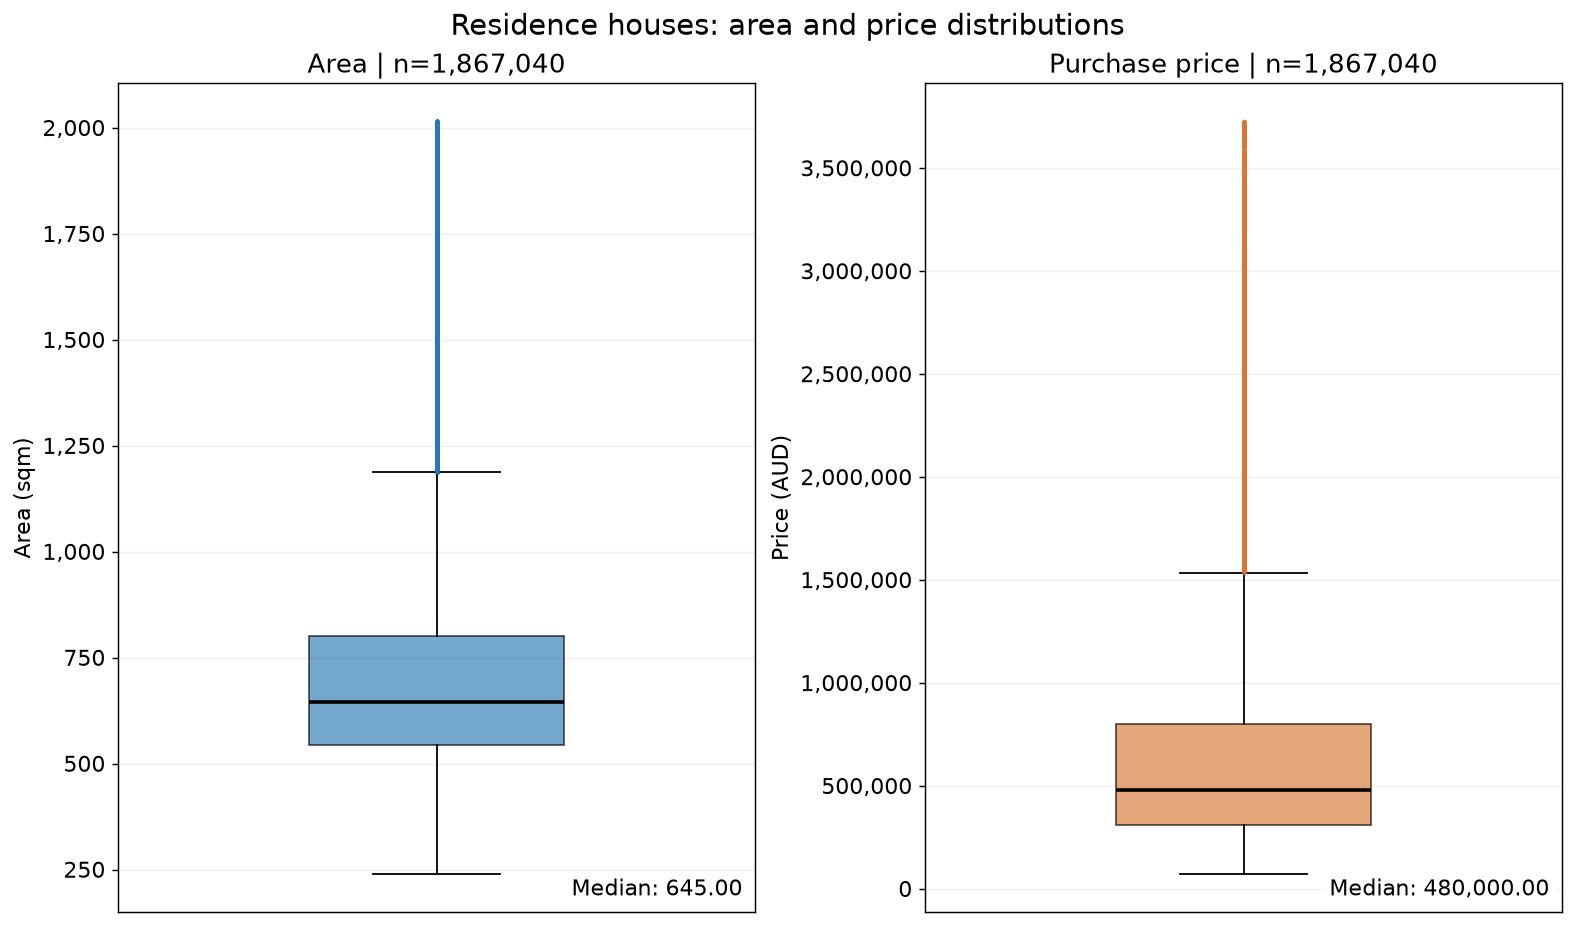

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

boxplot_fields = [
    ('area_sqm', 'Area', 'Area (sqm)', '#2878B5'),
    ('purchase_price', 'Purchase price', 'Price (AUD)', '#D97732'),
]
with plt.rc_context({'font.size': 12, 'figure.dpi': 130}):
    fig, axes = plt.subplots(1, 2, figsize=(12, 7), constrained_layout=True)
    for ax, (column, title, label, colour) in zip(axes, boxplot_fields):
        values = df_clean[column]
        values = values.loc[values.gt(0) & np.isfinite(values)]
        print(f'{column}: {len(values):,} plotted; {len(df_clean) - len(values):,} missing or invalid')
        if values.empty:
            ax.text(0.5, 0.5, 'No valid records', ha='center', transform=ax.transAxes)
            ax.set_title(title)
            continue
        ax.boxplot(
            values.to_numpy(), widths=0.4, whis=1.5, showfliers=True,
            patch_artist=True,
            boxprops={'facecolor': colour, 'alpha': 0.65},
            medianprops={'color': 'black', 'linewidth': 2},
            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.15,
                        'markeredgecolor': colour, 'rasterized': True},
        )
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y:,.0f}' if y >= 1 else f'{y:g}'))
        ax.set_xticks([])
        ax.set_ylabel(label)
        ax.set_title(f'{title} | n={len(values):,}')
        ax.grid(axis='y', alpha=0.2)
        median = values.median()
        ax.text(0.98, 0.02, f'Median: {median:,.2f}', transform=ax.transAxes,
                ha='right', bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'})
    fig.suptitle('Residence houses: area and price distributions', fontsize=16)
    plt.show()


## 10. Area and price distributions
Plot area and price separately using 60 equal-width bins on linear axes. Area is in square metres and price is in AUD. Vertical axes show transaction counts. Dashed lines show medians. Use all finite, positive cleaned values without further trimming or sampling.

area_sqm: 1,867,040 plotted; 0 missing or invalid
purchase_price: 1,867,040 plotted; 0 missing or invalid


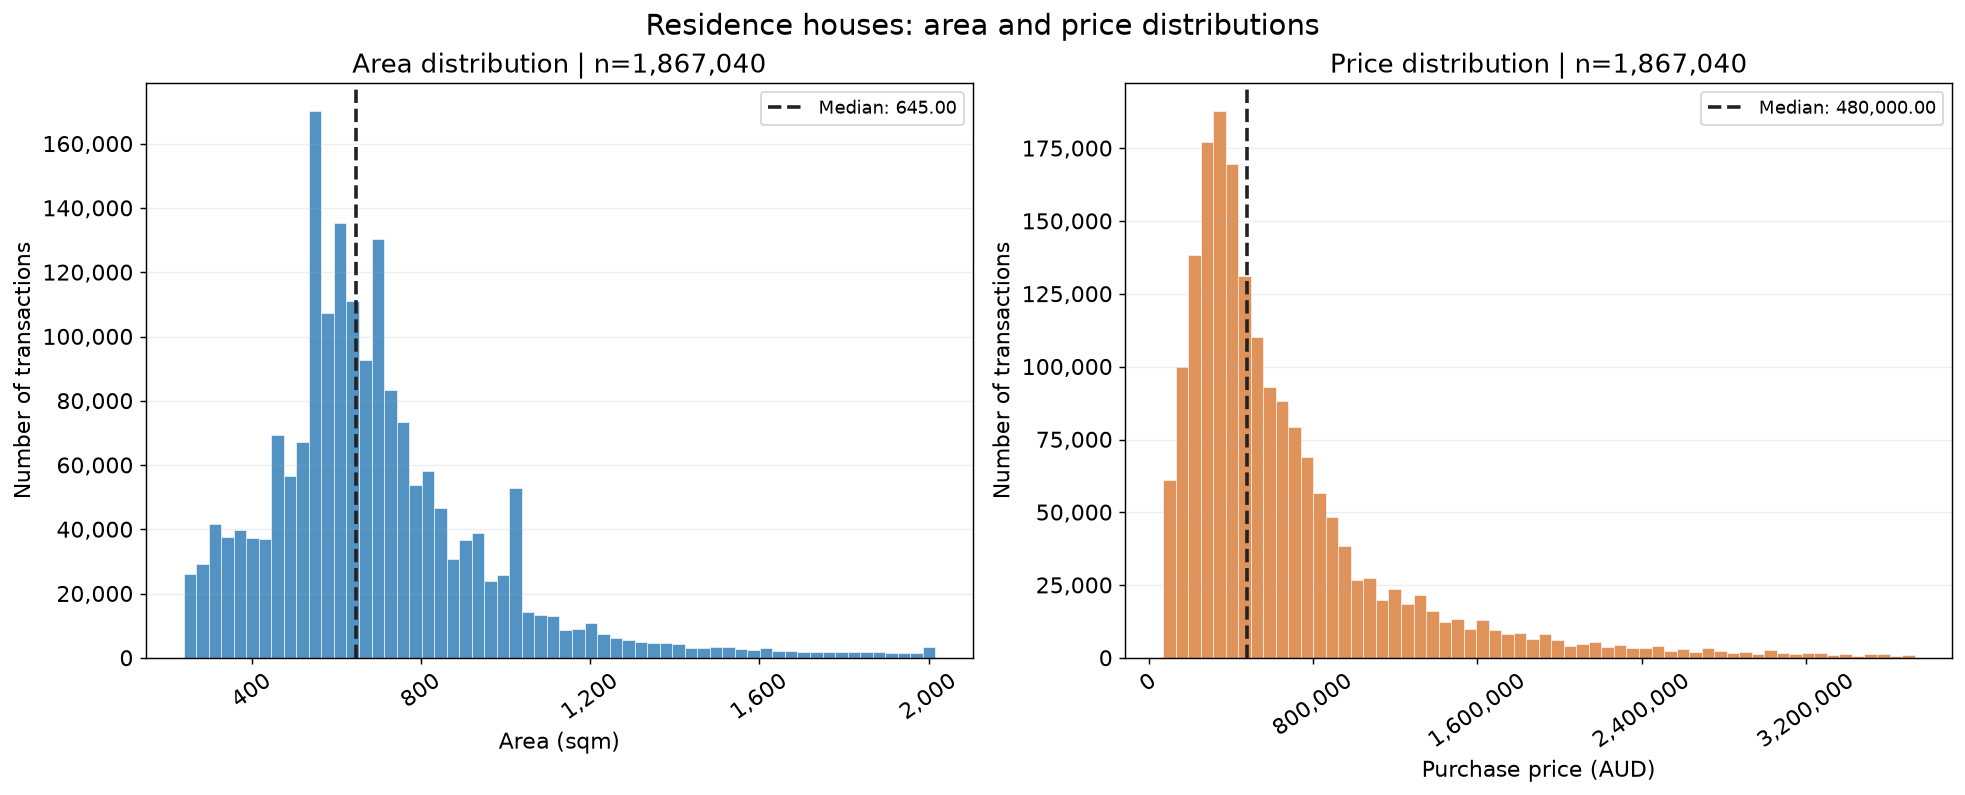

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

histogram_fields = [
    ('area_sqm', 'Area distribution', 'Area (sqm)', '#2878B5'),
    ('purchase_price', 'Price distribution', 'Purchase price (AUD)', '#D97732'),
]
with plt.rc_context({'font.size': 12, 'figure.dpi': 130}):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
    for ax, (column, title, label, colour) in zip(axes, histogram_fields):
        values = df_clean[column]
        values = values.loc[values.gt(0) & np.isfinite(values)]
        print(f'{column}: {len(values):,} plotted; {len(df_clean) - len(values):,} missing or invalid')
        if values.empty:
            ax.set_title(title)
            ax.text(0.5, 0.5, 'No valid records', ha='center', transform=ax.transAxes)
            continue
        low, high = values.min(), values.max()
        if low == high:
            low, high = low / 1.1, high * 1.1
        # Equal-width bins in original units; heights show record counts.
        bins = np.linspace(low, high, 61)
        ax.hist(values, bins=bins, color=colour, alpha=0.8,
                edgecolor='white', linewidth=0.4)
        median = values.median()
        ax.axvline(median, color='#222222', linestyle='--', linewidth=2,
                   label=f'Median: {median:,.2f}')
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}' if x >= 1 else f'{x:g}'))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y:,.0f}'))
        ax.tick_params(axis='x', labelrotation=35)
        ax.set_xlabel(label)
        ax.set_ylabel('Number of transactions')
        ax.set_title(f'{title} | n={len(values):,}')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.2)
    fig.suptitle('Residence houses: area and price distributions', fontsize=16)
    plt.show()


## 11. Optional export
When `SAVE_CSV` is True (the current setting), write `df_clean` to `nsw_residence_house_cleaned.csv`, replacing any previous export. The raw CSV remains unchanged. The export includes `area_sqm`, economic variables, development labels, locality, and four distance features; it excludes `area`, `area_type`, and the transport table's `sa4`.

In [18]:
SAVE_CSV = True
OUTPUT_PATH = Path('nsw_residence_house_cleaned.csv')
if SAVE_CSV:
    df_clean.to_csv(OUTPUT_PATH, index=False)
    print(f'Saved: {OUTPUT_PATH}')


Saved: nsw_residence_house_cleaned.csv


## Additional analysis: annual economic comparisons
Aggregate final cleaned residence-house prices by contract year and plot annual median, minimum, and maximum prices against the annual cash rate target (%) and supplied CPI index. Minima and maxima reflect prior outlier filtering. These are descriptive annual comparisons, not causal estimates; this section does not change the exported data.

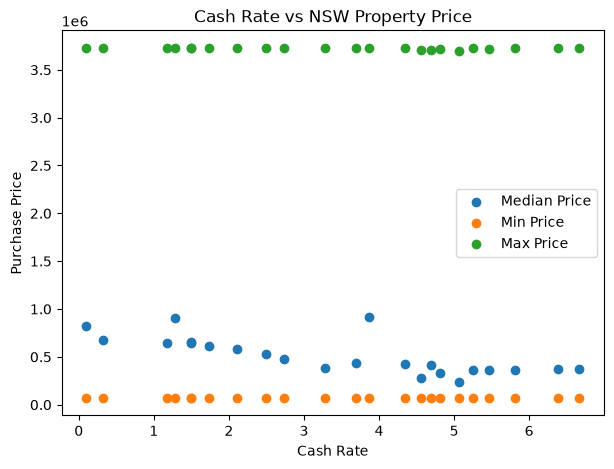

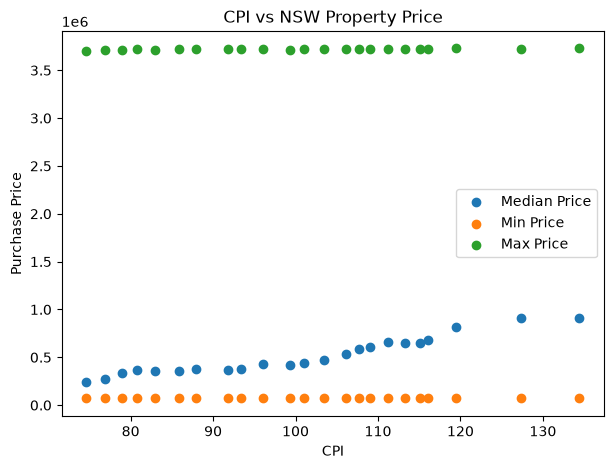

In [19]:
yearly_data = (
    df_clean.assign(year=df_clean['contract_date'].dt.year)
      .groupby('year')
      .agg(
          median_price=('purchase_price', 'median'),
          min_price=('purchase_price', 'min'),
          max_price=('purchase_price', 'max'),
          cash_rate=('cash_rate', 'first'),
          cpi=('cpi', 'first')
      )
      .reset_index()
)

yearly_data
plt.figure(figsize=(7, 5))

plt.scatter(
    yearly_data['cash_rate'],
    yearly_data['median_price'],
    label='Median Price'
)

plt.scatter(
    yearly_data['cash_rate'],
    yearly_data['min_price'],
    label='Min Price'
)

plt.scatter(
    yearly_data['cash_rate'],
    yearly_data['max_price'],
    label='Max Price'
)

plt.xlabel('Cash Rate')
plt.ylabel('Purchase Price')
plt.title('Cash Rate vs NSW Property Price')

plt.legend()
plt.show()
plt.figure(figsize=(7, 5))

plt.scatter(
    yearly_data['cpi'],
    yearly_data['median_price'],
    label='Median Price'
)

plt.scatter(
    yearly_data['cpi'],
    yearly_data['min_price'],
    label='Min Price'
)

plt.scatter(
    yearly_data['cpi'],
    yearly_data['max_price'],
    label='Max Price'
)

plt.xlabel('CPI')
plt.ylabel('Purchase Price')
plt.title('CPI vs NSW Property Price')

plt.legend()
plt.show()

---

# Part 2 — Area and price EDA

Relationship between property area and sale price.




# Area and Price EDA: Residence Houses
Use `nsw_residence_house_cleaned.csv` exported by `integrated_data_cleaning.ipynb`. Analyse recorded area in square metres and purchase price in AUD. No additional cleaning or outlier removal is applied.

Run in order. Requirements: pandas, numpy, matplotlib, and scipy. This analysis covers residence-purpose houses only. Location, contract year, CPI, and cash rate are not controlled for here.

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from IPython.display import display

DATA_PATH = Path('nsw_residence_house_cleaned.csv')
if not DATA_PATH.is_file():
    raise FileNotFoundError('Export the cleaned CSV from integrated_data_cleaning.ipynb first.')
columns = ['area_sqm', 'purchase_price', 'property_type', 'primary_purpose', 'contract_date']
df = pd.read_csv(DATA_PATH, usecols=columns,
                 dtype={'property_type': 'string', 'primary_purpose': 'string'},
                 parse_dates=['contract_date'])
fields = ['area_sqm', 'purchase_price']
assert df['property_type'].str.strip().str.lower().eq('house').fillna(False).all()
assert df['primary_purpose'].str.strip().str.upper().eq('RESIDENCE').fillna(False).all()
assert (df[fields].gt(0) & np.isfinite(df[fields])).all().all(), 'Recheck cleaning: area and price must be finite and positive.'
print(f'Analysis records: {len(df):,}')
print(f"Contract dates: {df.contract_date.min():%Y-%m-%d} to {df.contract_date.max():%Y-%m-%d}")
display(df.head())


Analysis records: 1,867,040
Contract dates: 2001-01-01 to 2023-12-31


,purchase_price,property_type,contract_date,primary_purpose,area_sqm
0,1500000,house,2023-11-17,RESIDENCE,727.2
1,985000,house,2023-09-27,RESIDENCE,992.7
2,1500000,house,2023-09-22,RESIDENCE,600.2
3,1500000,house,2023-11-27,RESIDENCE,600.7
4,1550000,house,2023-09-22,RESIDENCE,601.7


## 1. Descriptive statistics
Compare medians with means and upper percentiles to assess skew and extreme observations. All statistics use the full cleaned dataset.

In [21]:
summary = df[fields].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).T
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(summary)


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
area_sqm,"1,867,040.00",692.38,270.38,238.60,259.20,544.00,645.00,801.70,"1,190.00","1,718.00","2,015.80"
purchase_price,"1,867,040.00","657,279.72","551,846.46","70,100.00","92,500.00","310,000.00","480,000.00","800,000.00","1,800,000.00","2,900,000.00","3,728,000.00"


## 2. Area versus price
Show all records from the cleaned CSV on linear area and price axes, with no further trimming or sampling. Darker hexagons indicate more transactions; the colour scale is logarithmic to keep less dense regions visible.

The orange line connects median prices for up to 15 equal-frequency area groups, using each group's median area as its horizontal position. Groups need at least 30 records. This is a descriptive trend, not a fitted regression.

Records plotted: 1,867,040 (all cleaned records)


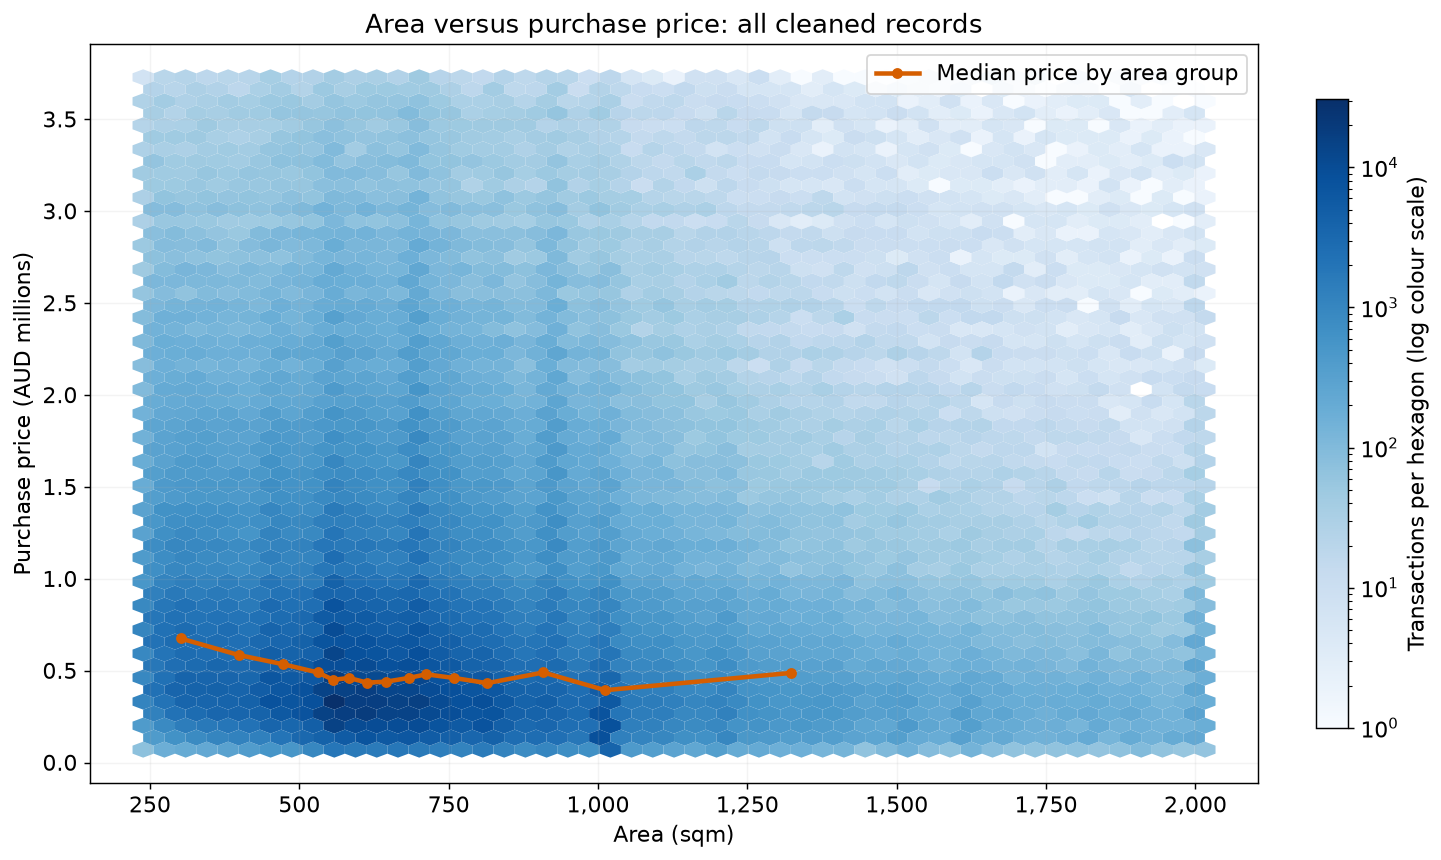

In [23]:
# Use all cleaned records for both the density plot and median trend.
trend_data = df[['area_sqm', 'purchase_price']].copy()
trend_data['area_bin'] = pd.qcut(trend_data['area_sqm'], q=15, duplicates='drop')
trend = trend_data.groupby('area_bin', observed=True).agg(
    area_median=('area_sqm', 'median'),
    price_median=('purchase_price', 'median'),
    records=('area_sqm', 'size'),
)
trend = trend.loc[trend['records'] >= 30]
print(f'Records plotted: {len(df):,} (all cleaned records)')

with plt.rc_context({'font.size': 12, 'figure.dpi': 130}):
    fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)
    density = ax.hexbin(
        df['area_sqm'], df['purchase_price'] / 1_000_000,
        gridsize=50, bins='log', mincnt=1, cmap='Blues', linewidths=0,
    )
    fig.colorbar(density, ax=ax, label='Transactions per hexagon (log colour scale)', shrink=0.85)
    ax.plot(trend['area_median'], trend['price_median'] / 1_000_000,
            '-o', color='#D55E00', linewidth=2.5, markersize=5,
            label='Median price by area group')
    ax.set_xscale('linear')
    ax.set_yscale('linear')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y:,.1f}'))
    ax.set_xlabel('Area (sqm)')
    ax.set_ylabel('Purchase price (AUD millions)')
    ax.set_title('Area versus purchase price: all cleaned records')
    ax.grid(alpha=0.15)
    ax.legend()
    plt.show()


## 3. Correlation
Pearson measures linear association; Spearman measures rank association. Log Pearson measures linear association after transforming both variables with log10. All three use the full cleaned dataset, matching the relationship plot. Correlation does not establish causation.

In [24]:
correlations = pd.DataFrame({
    'measure': ['Pearson', 'Spearman', 'Pearson (log10 area and price)'],
    'coefficient': [
        df.area_sqm.corr(df.purchase_price),
        df.area_sqm.corr(df.purchase_price, method='spearman'),
        np.log10(df.area_sqm).corr(np.log10(df.purchase_price)),
    ],
    'records': len(df),
})
display(correlations.round(4))


,measure,coefficient,records
0,Pearson,-0.0315,1867040
1,Spearman,-0.1082,1867040
2,Pearson (log10 area and price),-0.1112,1867040


## 4. Hypothesis 2: area and sale price per square metre
**Exploratory hypothesis:** larger recorded property areas are associated with lower sale prices per square metre among NSW residence-house transactions.

Define `price_per_sqm = purchase_price / area_sqm`. This allocates the total sale price to recorded area; it is not a pure land valuation or an indoor-floor-area price. Area appears both as the predictor and as the denominator, creating mathematical coupling. A negative association alone cannot demonstrate an economic area discount or causation.

In [25]:
# Divide total sale price by recorded area in square metres.
df['price_per_sqm'] = df['purchase_price'] / df['area_sqm']


### Area versus price per square metre
Display the joint 1st-99th percentile ranges on log axes, with coverage reported. The median trend uses all prices within the displayed area range before applying unit-price display limits. No records are deleted.

Density plot coverage: 1,798,174 of 1,867,040 records (96.3%)


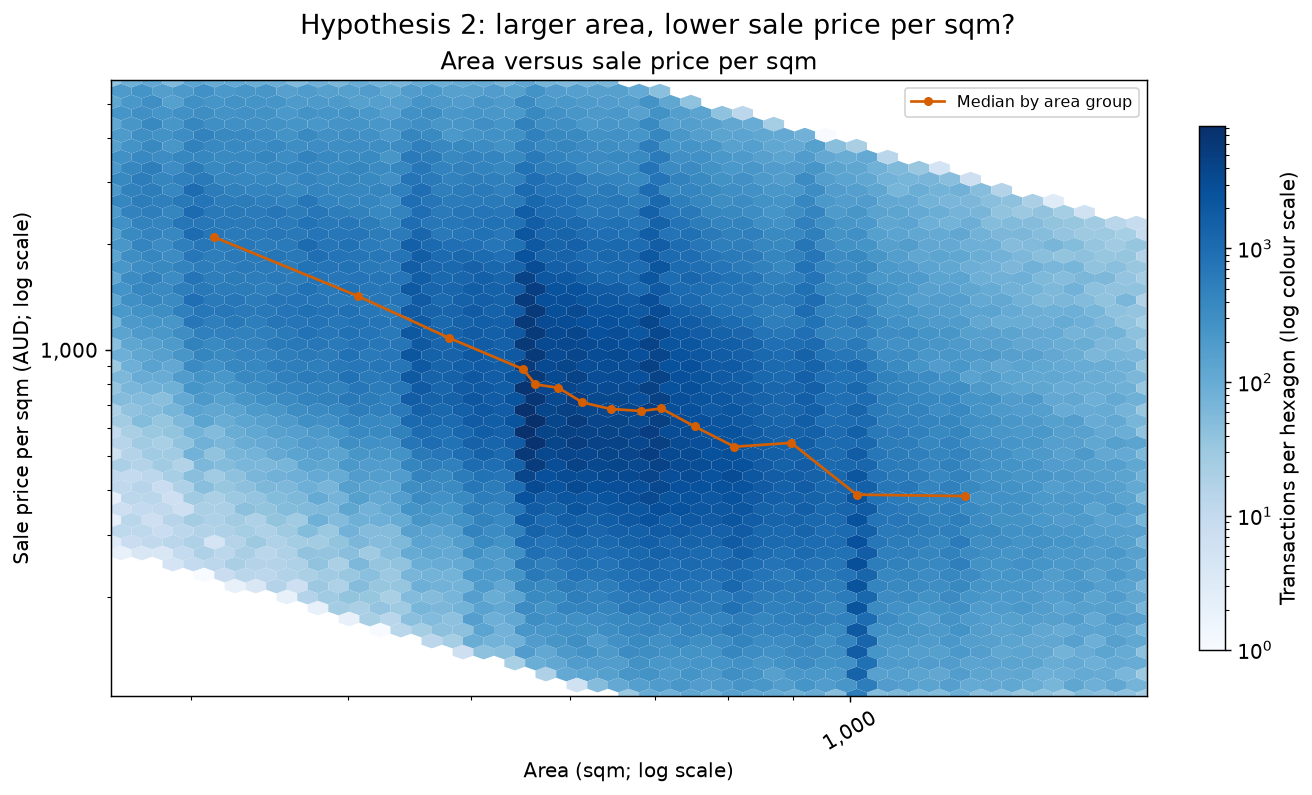

In [26]:
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

# Display the central ranges without removing records from the analysis.
limits = df[['area_sqm', 'price_per_sqm']].quantile([0.01, 0.99])
x_low, y_low = limits.loc[0.01]
x_high, y_high = limits.loc[0.99]
visible_unit_prices = df.loc[
    df.area_sqm.between(x_low, x_high) & df.price_per_sqm.between(y_low, y_high)
]
trend_unit_prices = df.loc[df.area_sqm.between(x_low, x_high), ['area_sqm', 'price_per_sqm']].copy()
trend_unit_prices['area_bin'] = pd.qcut(trend_unit_prices.area_sqm, q=15, duplicates='drop')
unit_price_trend = trend_unit_prices.groupby('area_bin', observed=True).agg(
    area_median=('area_sqm', 'median'),
    unit_price_median=('price_per_sqm', 'median'),
)
print(f'Density plot coverage: {len(visible_unit_prices):,} of {len(df):,} records ({len(visible_unit_prices) / len(df):.1%})')
with plt.rc_context({'font.size': 11, 'figure.dpi': 130}):
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    density = ax.hexbin(
        visible_unit_prices.area_sqm, visible_unit_prices.price_per_sqm,
        xscale='log', yscale='log', gridsize=50, bins='log', mincnt=1,
        cmap='Blues', linewidths=0,
    )
    fig.colorbar(density, ax=ax, label='Transactions per hexagon (log colour scale)', shrink=0.85)
    ax.plot(unit_price_trend.area_median, unit_price_trend.unit_price_median,
                 '-o', color='#D55E00', markersize=4, label='Median by area group')
    ax.set_xlim(x_low, x_high)
    ax.set_ylim(y_low, y_high)
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_locator(LogLocator(base=10, numticks=6))
        axis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:,.0f}' if v >= 1 else f'{v:g}'))
        axis.set_minor_formatter(NullFormatter())
    ax.set_xlabel('Area (sqm; log scale)')
    ax.set_ylabel('Sale price per sqm (AUD; log scale)')
    ax.set_title('Area versus sale price per sqm')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', labelrotation=30)
    fig.suptitle('Hypothesis 2: larger area, lower sale price per sqm?', fontsize=15)
    plt.show()


---

# Part 3 — Postcode and Metro analysis

Metro-station postcodes versus comparison postcodes.



# Postcode analysis using shared cleaned data
Read residence-house records with `development_type` computed before cleaning. The cleaning notebook builds postcode labels from 2011-2014 RESIDENCE/VACANT LAND house-classified transactions priced above AUD 10,000. Vacant share >=15% defines Greenfield; otherwise Established, with at least 50 baseline sales. Unsupported labels are missing and excluded from this analysis.

Retain the original postcode groups and the study window through 30 April 2023. The charts are descriptive comparisons, not causal station effects. 2023 includes January-April only. The 2011-2014 classification period is retrospective, not an independently verified pre-treatment period.

The 2014 marker denotes tunnelling, and the line opened on 26 May 2019. Sources: https://www.sydneymetro.info/about and https://www.nsw.gov.au/ministerial-releases/tunnelling-complete-on-sydney-metro-west


Area is read from `area_sqm` in square metres. The removed `area` and `area_type` columns are not required.

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path('nsw_residence_house_cleaned.csv')
cols = ['contract_date', 'purchase_price', 'post_code', 'property_type',
        'nature_of_property', 'primary_purpose', 'area_sqm', 'development_type']
raw = pd.read_csv(DATA_PATH, usecols=cols, dtype={'post_code': 'string'}, low_memory=False)
raw['contract_date'] = pd.to_datetime(raw['contract_date'], errors='raise')

# area_sqm is already in square metres; no area_type conversion is needed.
raw['area_sqm'] = pd.to_numeric(raw['area_sqm'], errors='raise')
assert (raw['area_sqm'].gt(0) & np.isfinite(raw['area_sqm'])).all(), 'Invalid cleaned area_sqm values.'
purposes = raw.primary_purpose.str.strip().str.upper()
assert purposes.eq('RESIDENCE').all()
assert raw.property_type.str.lower().eq('house').all()
print(f'Cleaned input records: {len(raw):,}')
print(purposes.value_counts().to_string())


Cleaned input records: 1,867,040
primary_purpose
RESIDENCE    1867040


In [28]:
URL = "https://raw.githubusercontent.com/matthewproctor/australianpostcodes/master/australian_postcodes.csv"
POSTCODE_PATH = Path('australian_postcodes.csv')
pc = pd.read_csv(POSTCODE_PATH if POSTCODE_PATH.exists() else URL, low_memory=False)

pc = pc[(pc.state == "NSW") & (pc.type == "Delivery Area")
        & (pc.postcode >= 2000) & pc.lat.notna() & (pc.lat != 0)]

cent = (pc.groupby("postcode")
          .agg(locality=("locality", "first"), sa4=("sa4name", "first"))
          .reset_index())
print(f"NSW postcodes with a region label: {len(cent)}")


NSW postcodes with a region label: 620


In [29]:
# Use the development labels already assigned before cleaning.
r = raw.loc[raw.contract_date.between('2001-01-01', '2023-04-30')
            & raw.purchase_price.gt(10000)].copy()
r['post_code'] = pd.to_numeric(r['post_code'], errors='coerce')
r['year'] = r.contract_date.dt.year
print(f'Excluded rows without supported postcode labels: {r.development_type.isna().sum():,}')
df = r.dropna(subset=['development_type']).copy()
assert df.development_type.isin(['Established', 'Greenfield']).all()
assert df.groupby('post_code').development_type.nunique().le(1).all()
METRO_PC = [2126, 2153, 2154, 2155, 2762]
NW_SA4 = ['Sydney - Ryde', 'Sydney - Parramatta',
          'Sydney - Baulkham Hills and Hawkesbury', 'Sydney - Blacktown']
print(df.loc[df.post_code.isin(METRO_PC), ['post_code', 'development_type']].drop_duplicates().sort_values('post_code').to_string(index=False))


Excluded rows without supported postcode labels: 0
 post_code development_type
      2126      Established
      2153      Established
      2154      Established
      2155       Greenfield
      2762       Greenfield


In [30]:
panel = (df.groupby(['post_code', 'year'])
         .agg(median_price=('purchase_price', 'median'),
              n_sales=('purchase_price', 'size'), dev=('development_type', 'first'))
         .reset_index()
         .merge(cent, left_on='post_code', right_on='postcode', how='inner', validate='many_to_one'))
panel = panel.loc[panel.sa4.isin(NW_SA4)].copy()
panel['stn'] = np.where(panel.post_code.isin(METRO_PC), 'Station', 'No station')
panel['cell'] = panel.dev + ' / ' + panel.stn
print('Postcodes per group:')
print(panel.groupby('cell').post_code.nunique().to_string())


Postcodes per group:
cell
Established / No station    40
Established / Station        3
Greenfield / No station      7
Greenfield / Station         2


In [31]:
price = (panel[panel.n_sales >= 20]
         .pivot_table(index="year", columns="cell", values="median_price", aggfunc="median"))
idx = (price / price.loc[2011] * 100).round(1)

print("=== Median house price index (2011 = 100) ===")
print(idx.loc[2011:].to_string(), "\n")

print("=== Parallel-trend check: Established, Station minus No station ===")
gap = idx["Established / Station"] - idx["Established / No station"]
print(gap.loc[2011:2015].round(1).to_string())
print("\n=== Observed station/non-station index gap in 2023 (percentage points) ===")
for d in ["Established", "Greenfield"]:
    print(f"  {d:12s} {idx.loc[2023, f'{d} / Station'] - idx.loc[2023, f'{d} / No station']:+6.1f}")


=== Median house price index (2011 = 100) ===
cell  Established / No station  Established / Station  Greenfield / No station  Greenfield / Station
year                                                                                                
2011                     100.0                  100.0                    100.0                 100.0
2012                     102.3                  101.5                    108.8                 105.8
2013                     118.8                  116.0                    118.5                 106.9
2014                     140.8                  139.0                    139.0                 119.5
2015                     178.8                  177.9                    165.7                 144.0
2016                     176.0                  185.8                    182.1                 163.8
2017                     208.8                  205.9                    192.8                 188.3
2018                     187.4               

In [32]:
vol = panel.pivot_table(index="year", columns="cell", values="n_sales", aggfunc="median")
print("=== Median house sales per postcode per year ===")
print(vol.loc[2011:2022].round(0).to_string(), "\n")

print("=== Observed station/non-station sales difference, 2021 ===")
for d in ["Established", "Greenfield"]:
    a, b = vol.loc[2021, f"{d} / No station"], vol.loc[2021, f"{d} / Station"]
    print(f"  {d:12s} {a:,.0f} -> {b:,.0f}   ({b-a:+,.0f})")


=== Median house sales per postcode per year ===
cell  Established / No station  Established / Station  Greenfield / No station  Greenfield / Station
year                                                                                                
2011                     176.0                  444.0                    136.0                 424.0
2012                     158.0                  457.0                    214.0                 412.0
2013                     208.0                  530.0                    162.0                 586.0
2014                     210.0                  529.0                    128.0                 695.0
2015                     188.0                  432.0                    143.0                 597.0
2016                     156.0                  427.0                    182.0                 536.0
2017                     146.0                  409.0                    171.0                 550.0
2018                     116.0            

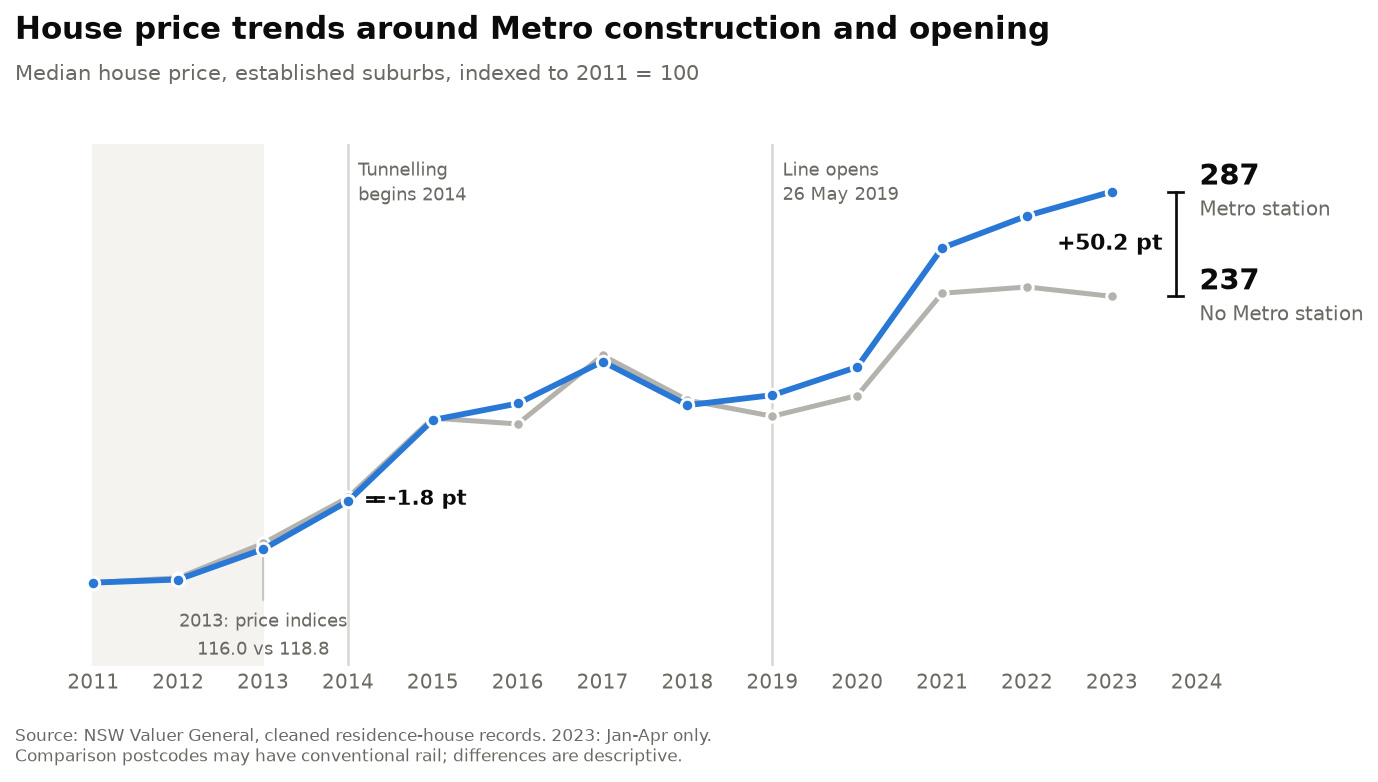

In [33]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

ACC, GREY = '#2a78d6', '#b4b2ac'
SUR, INK, INK2 = '#ffffff', '#0b0b0b', '#6b6963'
fig, ax = plt.subplots(figsize=(10.4, 5.2), dpi=150)
fig.patch.set_facecolor(SUR)
ax.set_facecolor(SUR)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors=INK2, labelsize=9.5, length=0)
ax.grid(False)

e = idx.loc[2011:]
S = e['Established / Station']
N = e['Established / No station']
ax.axvspan(2011, 2013, color='#f4f3f0', zorder=0)
ax.plot(N.index, N, color=GREY, lw=2.4, marker='o', ms=5.5, mec=SUR, mew=1.4, zorder=3)
ax.plot(S.index, S, color=ACC, lw=2.8, marker='o', ms=6, mec=SUR, mew=1.4, zorder=4)


def bracket(x, lo, hi, text, side='right', fs=10.5):
    ax.plot([x, x], [lo, hi], color=INK, lw=1.3, clip_on=False, zorder=6)
    for yy in (lo, hi):
        ax.plot([x - .09, x + .09], [yy, yy], color=INK, lw=1.3, clip_on=False, zorder=6)
    dx, ha = (6, 'left') if side == 'right' else (-6, 'right')
    ax.annotate(text, (x, (lo + hi) / 2), xytext=(dx, 0), textcoords='offset points',
                va='center', ha=ha, color=INK, fontsize=fs, fontweight='bold', zorder=7)


# Derive annotations from the current cleaned-data results.
last_year = int(e.dropna(subset=['Established / Station', 'Established / No station']).index.max())
bracket(2014.32, N.loc[2014], S.loc[2014], f'{S.loc[2014] - N.loc[2014]:+.1f} pt', 'right', 10)
bracket(last_year + .75, N.loc[last_year], S.loc[last_year],
        f'{S.loc[last_year] - N.loc[last_year]:+.1f} pt', 'left', 10.5)
for series, name in [(S, 'Metro station'), (N, 'No Metro station')]:
    value = series.loc[last_year]
    ax.annotate(f'{value:.0f}', (last_year, value), xytext=(42, 7),
                textcoords='offset points', va='center', color=INK, fontsize=14, fontweight='bold')
    ax.annotate(name, (last_year, value), xytext=(42, -9),
                textcoords='offset points', va='center', color=INK2, fontsize=9.5)
ax.annotate(f'2013: price indices\n{S.loc[2013]:.1f} vs {N.loc[2013]:.1f}',
            (2013, (S.loc[2013] + N.loc[2013]) / 2), xytext=(0, -52),
            textcoords='offset points', ha='center', color=INK2, fontsize=8.5,
            linespacing=1.5, arrowprops={'arrowstyle': '-', 'color': '#c9c7c1', 'lw': 1})

upper = max(310, max(S.max(), N.max()) * 1.08)
ax.set_xlim(2010.5, last_year + 1.1)
ax.set_ylim(60, upper)
ax.set_yticks([])
ax.xaxis.set_major_locator(MultipleLocator(1))
for year, label in [(2014, 'Tunnelling\nbegins 2014'), (2019, 'Line opens\n26 May 2019')]:
    ax.axvline(year, color='#d8d6d0', lw=1.2, zorder=1)
    ax.text(year + .12, upper - 7, label, color=INK2, fontsize=8.5, va='top', linespacing=1.4)
fig.text(.012, .965, 'House price trends around Metro construction and opening',
         color=INK, fontsize=15, fontweight='bold', va='top')
fig.text(.012, .902, 'Median house price, established suburbs, indexed to 2011 = 100',
         color=INK2, fontsize=10, va='top')
fig.text(.012, .008, 'Source: NSW Valuer General, cleaned residence-house records. 2023: Jan-Apr only.\n'
         'Comparison postcodes may have conventional rail; differences are descriptive.',
         color=INK2, fontsize=8)
plt.subplots_adjust(top=.80, bottom=.13, left=.035, right=.775)
plt.savefig('fig1_timing.png', facecolor=SUR, dpi=150)
plt.show()


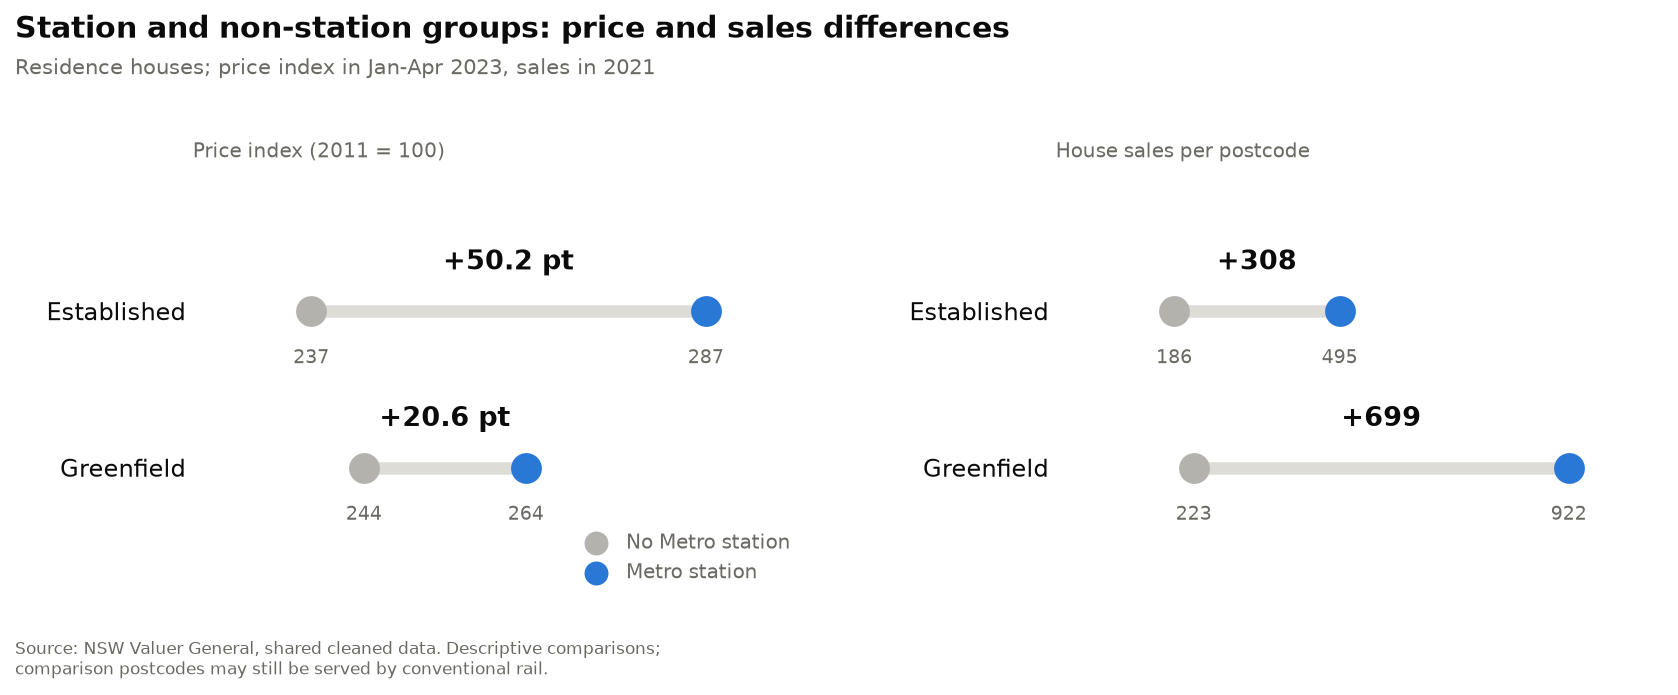

In [34]:
D = ['Established', 'Greenfield']
LBL_Y, LBL_N = 'Metro station', 'No Metro station'

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6), dpi=150)
fig.patch.set_facecolor(SUR)
panels = [
    (idx, 2023, 'Price index (2011 = 100)', '{:+.1f} pt', '{:.0f}'),
    (vol, 2021, 'House sales per postcode', '{:+,.0f}', '{:,.0f}'),
]
for ax, (tbl, yr, sub, gap_format, value_format) in zip(axes, panels):
    ax.set_facecolor(SUR)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=INK2, labelsize=9.5, length=0)
    ax.grid(False)
    ax.set_xticks([])

    ys = [1, 0]
    lo = [tbl.loc[yr, f'{group} / No station'] for group in D]
    hi = [tbl.loc[yr, f'{group} / Station'] for group in D]
    for y, a, b in zip(ys, lo, hi):
        ax.plot([a, b], [y, y], color='#dedcd6', lw=6, zorder=2, solid_capstyle='round')
        ax.scatter([a], [y], s=190, color=GREY, zorder=4)
        ax.scatter([b], [y], s=190, color=ACC, zorder=4)
        ax.annotate(gap_format.format(b - a), ((a + b) / 2, y), xytext=(0, 20),
                    textcoords='offset points', ha='center', color=INK,
                    fontsize=13, fontweight='bold')
        for value in (a, b):
            ax.annotate(value_format.format(value), (value, y), xytext=(0, -25),
                        textcoords='offset points', ha='center', color=INK2, fontsize=9)

    # Derive the display range from both groups.
    lower, upper = min(lo + hi), max(lo + hi)
    span = max(upper - lower, 1)
    ax.set_xlim(lower - span * .30, upper + span * .24)
    ax.set_ylim(-.8, 1.8)
    ax.set_yticks(ys)
    ax.set_yticklabels(D, fontsize=11.5, color=INK)
    ax.text(0, 1.07, sub, transform=ax.transAxes, color=INK2, fontsize=9.5)

axes[0].scatter([], [], s=110, color=GREY, label=LBL_N)
axes[0].scatter([], [], s=110, color=ACC, label=LBL_Y)
axes[0].legend(frameon=False, fontsize=9.5, labelcolor=INK2,
               loc='lower right', handletextpad=.5, borderpad=0)
fig.text(.011, .968, 'Station and non-station groups: price and sales differences',
         color=INK, fontsize=14.5, fontweight='bold', va='top')
fig.text(.011, .905, 'Residence houses; price index in Jan-Apr 2023, sales in 2021',
         color=INK2, fontsize=10, va='top')
fig.text(.011, .012, 'Source: NSW Valuer General, shared cleaned data. Descriptive comparisons;\n'
         'comparison postcodes may still be served by conventional rail.', color=INK2, fontsize=8)
plt.subplots_adjust(top=.72, bottom=.13, left=.115, right=.975, wspace=.42)
plt.savefig('fig2_price_vs_volume.png', facecolor=SUR, dpi=150)
plt.show()


In [35]:
yr = raw.contract_date.dt.year
print("Date range:", raw.contract_date.min(), "->", raw.contract_date.max())
print("Records before 2001:", (yr < 2001).sum())
print("Records after 2023: ", (yr > 2023).sum())
print("Unparseable dates:  ", raw.contract_date.isna().sum())

print("\n=== Counts below candidate thresholds in cleaned input ===")
for t in [1, 100, 1000, 10000, 50000]:
    print(f"  Price below ${t:>6,}: {(raw.purchase_price < t).sum():>7,} records")

print("\n=== nature_of_property ===");  print(raw.nature_of_property.value_counts())
print("\n=== property_type ===");       print(raw.property_type.value_counts())


Date range: 2001-01-01 00:00:00 -> 2023-12-31 00:00:00
Records before 2001: 0
Records after 2023:  0
Unparseable dates:   0

=== Counts below candidate thresholds in cleaned input ===
  Price below $     1:       0 records
  Price below $   100:       0 records
  Price below $ 1,000:       0 records
  Price below $10,000:       0 records
  Price below $50,000:       0 records

=== nature_of_property ===
nature_of_property
R    1867014
3         26
Name: count, dtype: int64

=== property_type ===
property_type
house    1867040
Name: count, dtype: int64
